### 1.1 Montrer que les matrices de réflexion $Q_i$ sont orthogonales

#### 1. Orthogonalité d’une matrice de Householder

Une matrice de Householder est définie par :

$$
H = I - 2\frac{v v^T}{v^T v},
$$

où $v \neq 0$.  
On veut démontrer que :

$$
H^T H = I.
$$

Comme $v v^T$ est symétrique :

$$
(v v^T)^T = v v^T,
$$
Deux matrices, une colonne et l'autre ligne de même longueure et identique, donnera le même résultats malgré la transposée.

Donc :

$$
H^T = H.
$$

Ainsi :

$$
H^T H = H^2.
$$

Calculons $H^2$ :

$$
H^2
= \left(I - 2\frac{v v^T}{v^T v}\right)^2
= I - 4\frac{v v^T}{v^T v}
  + 4\frac{v v^T v v^T}{(v^T v)^2}.
$$

Nous savons que :

$$
v v^T v = (v^T v) v,
$$

donc :

$$
v v^T v v^T = (v^T v) v v^T.
$$

Ainsi :

$$
4\frac{v v^T v v^T}{(v^T v)^2}
= 4\frac{(v^T v) v v^T}{(v^T v)^2}
= 4\frac{v v^T}{v^T v}.
$$

En substituant :

$$
H^2
= I - 4\frac{v v^T}{v^T v}
  + 4\frac{v v^T}{v^T v}
= I.
$$

Donc :

$$
H^T H = I,
$$

ce qui montre que toute matrice de Householder est orthogonale.

---

#### 2. Orthogonalité des matrices $Q_i$ ####

Les matrices $Q_i$ sont définies par blocs :

$$
Q_i =
\begin{pmatrix}
I_i & 0 \\
0 & H_{m,i}
\end{pmatrix}.
$$

La transposée est :

$$
Q_i^T =
\begin{pmatrix}
I_i & 0 \\
0 & H_{m,i}^T
\end{pmatrix}
=
\begin{pmatrix}
I_i & 0 \\
0 & H_{m,i}
\end{pmatrix},
$$

puisque $I_i$  et  $H_{m,i}$ sont symétriques.

Alors :

$$
Q_i^T Q_i =
\begin{pmatrix}
I_i & 0 \\
0 & H_{m,i}
\end{pmatrix}
\begin{pmatrix}
I_i & 0 \\
0 & H_{m,i}
\end{pmatrix}
=
\begin{pmatrix}
I_i & 0 \\
0 & H_{m,i}H_{m,i}
\end{pmatrix}.
$$

Comme $H_{m,i}$ est orthogonale :

$$
H_{m,i}H_{m,i} = I_{m-i}.
$$

Donc :

$$
Q_i^T Q_i = I_m.
$$

Ainsi, chaque matrice $Q_i$ est orthogonale.

### 2 Mesures imprécises dans un jeu de bataille navale

#### 2.1 Modification du code de décomposition de QR

In [ ]:
import numpy as np
import xlwings as xw
import matplotlib.pyplot as plt

# ouvrir le fichier Excel
wb = xw.Book('bataille_navale_equipe050.csv')

# sélectionner une feuille
sheet = wb.sheets['bataille_navale_equipe050']

# lire une cellule
Coordonne_x = sheet.range('A2:A9').value
Coordonne_y = sheet.range('B2:B9').value
print(Coordonne_x)
print(Coordonne_y)

A = np.zeros((len(Coordonne_x),4))


for i in range(len(Coordonne_x)):
    A[i,0] = 1
    A[i,1] = Coordonne_x[i]
    A[i,2] = Coordonne_x[i]**2
    A[i,3] = Coordonne_y[i]

print(A)
def householder_qr(A):
    """Calcule la décomposition QR d’une matrice A en utilisant les réflexions de Householder. """
    
    m, n = A.shape  # donne les valeurs correspondantes à m et n de la matrice A
    Q = np.eye(m)   # Crée une matrice identité de taille m x m pour stocker les transformations de Householder
    R = A.copy()    # Crée une copie de la matrice A pour stocker les résultats de la décomposition

    for k in range(n):  # on passe au travers de chaque colonne de la matrice A

        # Extract the column vector to be transformed
        x = R[k:, k]  # vecteur colonne tronqué à partir de la ligne k et de la colonne k

        # Compute the Householder vector
        e = np.zeros_like(x)  # Crée un vecteur de même taille que x, rempli de zéros
        sign = 1 if x[0] >= 0 else -1  # Choisit le signe pour éviter les problèmes de cancellation numérique
        e[0] = sign * np.linalg.norm(x)  # Met la norme de x dans la première composante du vecteur e

        u = x + e  # Calcule le vecteur de Householder selon la définition du TP (x + sign*||x||*e1)
        beta = u @ u  # Calcule u^T u (un scalaire), utilisé dans la formule de Householder

        if beta == 0:  # Cas dégénéré : aucune transformation nécessaire
            continue

        # Create the Householder matrix
        H_k = np.eye(m)  # Matrice identité m x m
        H_k[k:, k:] -= 2 * np.outer(u, u) / beta  # Applique la formule H = I - 2 uu^T / (u^T u)

        # Apply the transformation to R and accumulate Q
        R = H_k @ R  # Applique la réflexion à R pour annuler les éléments sous la diagonale
        Q = Q @ H_k  # Accumule les transformations pour construire la matrice Q finale


    return Q, R

 

Q, R = householder_qr(A)       
print("R:\n", R)
print("Verification (Q @ R == A):", np.allclose(Q @ R, A))

[2635.01796295324, 2564.31109162505, 2493.55845637202, 2422.8958772041, 2352.12613749554, 2281.42637488933, 2210.70350039799, 2139.98934105288]
[10.5950280022769, 160.220694291491, 304.4563807953, 438.606686747962, 567.445625512324, 681.158037160169, 793.070284088819, 891.761432720425]
[[1.00000000e+00 2.63501796e+03 6.94331967e+06 1.05950280e+01]
 [1.00000000e+00 2.56431109e+03 6.57569137e+06 1.60220694e+02]
 [1.00000000e+00 2.49355846e+03 6.21783378e+06 3.04456381e+02]
 [1.00000000e+00 2.42289588e+03 5.87042443e+06 4.38606687e+02]
 [1.00000000e+00 2.35212614e+03 5.53249737e+06 5.67445626e+02]
 [1.00000000e+00 2.28142637e+03 5.20490630e+06 6.81158037e+02]
 [1.00000000e+00 2.21070350e+03 4.88720997e+06 7.93070284e+02]
 [1.00000000e+00 2.13998934e+03 4.57955438e+06 8.91761433e+02]]
R:
 [[-2.82842712e+00 -6.75287992e+03 -1.61967890e+07 -1.36023097e+03]
 [ 1.69587671e-16 -4.58312144e+02 -2.18844382e+06  8.17141081e+02]
 [-1.69586388e-16  1.68649309e-15  6.48216743e+04 -5.53421834e+01]
 [-

### 2.2 Résolution approximative de l'équation

In [60]:
a_2 = R[2,3]/R[2,2]
a_1 = (R[1,3]-R[1,2]*a_2)/R[1,1]
a_0 = (R[0,3]-R[0,2]*a_2-R[0,1]*a_1)/R[0,0]


print(f"y(x) = {a_2}x^2+{a_1}x+{a_0}]")



y(x) = -0.0008537604741404132x^2+2.293776773615609x+-106.48671685423868]


### 2.3 Trajectoir prédite


[2635.01796295324, 2564.31109162505, 2493.55845637202, 2422.8958772041, 2352.12613749554, 2281.42637488933, 2210.70350039799, 2139.98934105288]
[10.5950280022769, 160.220694291491, 304.4563807953, 438.606686747962, 567.445625512324, 681.158037160169, 793.070284088819, 891.761432720425]


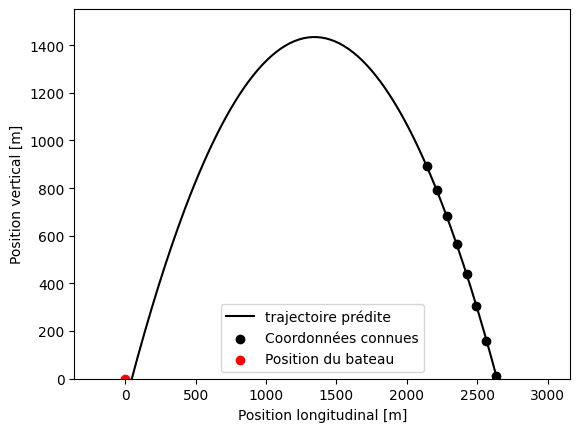

In [66]:
import xlwings as xw
import matplotlib.pyplot as plt
import numpy as np


# ouvrir le fichier Excel
wb = xw.Book('bataille_navale_equipe050.csv')

# sélectionner une feuille
sheet = wb.sheets['bataille_navale_equipe050']

# lire une cellule
Coordonne_x = sheet.range('A2:A9').value
Coordonne_y = sheet.range('B2:B9').value
print(Coordonne_x)
print(Coordonne_y)

Coordonne_x_predit = np.linspace(-200, 3000, 200)
Coordonne_y_predit = []


def trajectoire(x):
    return a_2*x**2+a_1*x+a_0   
   
for i in Coordonne_x_predit:
    Coordonne_y_predit.append(trajectoire(i))
             
plt.plot(Coordonne_x_predit, Coordonne_y_predit, color="black", label="trajectoire prédite")
plt.scatter(Coordonne_x, Coordonne_y, color="black", label="Coordonnées connues")
plt.scatter(0, 0, color="red", label="Position du bateau")
plt.ylim(bottom=0)
plt.legend()
plt.xlabel("Position longitudinal [m]")
plt.ylabel("Position vertical [m]")
plt.show()


### 2.4 Position de l'impact du projectil avec la méthode de la bissection

La résolution pour y=0 en utilisant la méthode de la bissection trouve un zéro à: 47.25534904120315
La résolution pour y=0 en utilisant la méthode de la bissection trouve un zéro à: 2639.419477320417


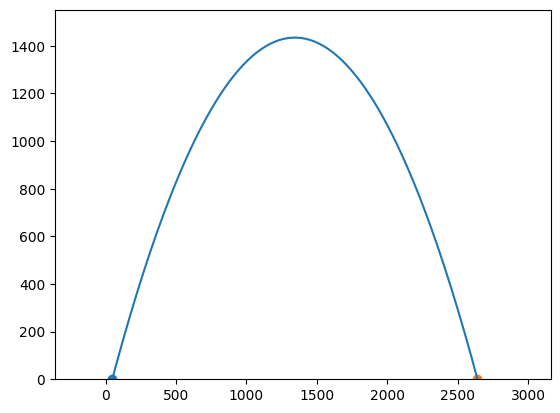

In [67]:
import numpy as np


n = 10000

Y = []

def f(x):
    return trajectoire(x)

for i in Coordonne_x_predit:
    Y.append(f(i))

def trouve_zero(a, b):
    if f(a)*f(b) > 0 :
        print("erreur, f(a) et f(b) sont de même signe. Faute initiale.")
        
    else:
        for i in range(100):
            f_a = f(a)
            f_b = f(b)
            f_m = f((a+b)/2)
            if f_a*f_m <= 0:
                b = (a+b)/2

            elif f_b*f_m <= 0:
                a = (a+b)/2

            else:
                print("erreur, f(a) et f(b) sont de même signe. Faute lors de la résolution.")
                break

        print(f"La résolution pour y=0 en utilisant la méthode de la bissection trouve un zéro à: {(a+b)/2}")
        plt.scatter((a+b)/2, f((a+b)/2))

trouve_zero(-500, 500)
trouve_zero(2500, 3000)
plt.plot(Coordonne_x_predit,Y)
plt.ylim(bottom=0)
plt.show()

Étant donné que le tir terminera sa course à 47.25 mètres de notre position, nous pouvons conclure que nous seront en sécurité si notre embarcation est de faible taille (un kayak par exemple). Cependant, si notre embarcation mesure plus de 47.25 mètres tel le USNS Apalachicola (103 mètres) ou même une frégates de classe Halifax (100 mètres), il se pourrait que le projectil nous touche dépendament de notre orientation.